# lumerical_tuned_beam_splitter.ipynb

Self-contained workflow:
  1. Generate tuned directional-coupler beam splitter GDS
  2. Add 20 um straight waveguide extension at each port
  3. Save to gds/tuned_beam_splitter.gds
  4. Open Lumerical
  5. Import the GDS as 220 nm Si using fitted Si Palik material

Units:
  gdsfactory layout units: um
  Lumerical units: m

## Imports and paths

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import gdsfactory as gf

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
GDS_DIR = Path("gds")
GDS_DIR.mkdir(exist_ok=True)

gds_path = GDS_DIR / "tuned_beam_splitter.gds"
param_json_path = GDS_DIR / "tuned_beam_splitter_parameters.json"

print(f"GDS folder: {GDS_DIR.resolve()}")
print(f"GDS path:   {gds_path.resolve()}")

GDS folder: C:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Beam Splitter Simulation\gds
GDS path:   C:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Beam Splitter Simulation\gds\tuned_beam_splitter.gds


## Design parameters you import/change

In [2]:
# Waveguide geometry
wg_width_um = 0.300          # 500 nm
gap_um = 0.250               # 150 nm edge-to-edge gap

# Coupling length from supermode analysis
coupling_length_um = 1.772    # replace with your tuned L_50/50

pitch = 4                    # waveguide pitch in um

# S-bend routing
sbend_x_um = 25.0            # horizontal S-bend length
sbend_y_um = pitch/2 - gap_um/2 - wg_width_um/2  # vertical S-bend offset


# Important:
# These are the straight waveguide extensions added at all four ports.
port_straight_um = 20.0

# GDS layers
WG_LAYER = (1, 0)
LABEL_LAYER = (10, 0)

# Polygon sampling
num_sbend_points = 151
num_straight_points = 40

print("Tuned beam splitter settings")
print("----------------------------")
print(f"wg_width_um         = {wg_width_um:.3f}")
print(f"gap_um              = {gap_um:.3f}")
print(f"coupling_length_um  = {coupling_length_um:.3f}")
print(f"sbend_x_um          = {sbend_x_um:.3f}")
print(f"sbend_y_um          = {sbend_y_um:.3f}")
print(f"port_straight_um    = {port_straight_um:.3f}")

Tuned beam splitter settings
----------------------------
wg_width_um         = 0.300
gap_um              = 0.250
coupling_length_um  = 1.772
sbend_x_um          = 25.000
sbend_y_um          = 1.725
port_straight_um    = 20.000


## Full GDS-generation code

In [3]:
def smoothstep(t: np.ndarray) -> np.ndarray:
    """
    Cubic smoothstep interpolation from 0 to 1.

    y(t) = 3t^2 - 2t^3

    This gives zero slope at both ends, which is good for S-bends.
    """
    return 3 * t**2 - 2 * t**3


def make_sbend_centerline(
    x0: float,
    x1: float,
    y0: float,
    y1: float,
    npoints: int = 151,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns a smooth S-bend centerline between (x0, y0) and (x1, y1).
    """
    t = np.linspace(0, 1, npoints)
    x = x0 + (x1 - x0) * t
    y = y0 + (y1 - y0) * smoothstep(t)
    return x, y


def make_straight_centerline(
    x0: float,
    x1: float,
    y: float,
    npoints: int = 40,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns a straight centerline from x0 to x1 at fixed y.
    """
    x = np.linspace(x0, x1, npoints)
    yarr = np.full_like(x, y)
    return x, yarr


def centerline_to_polygon(
    x: np.ndarray,
    y: np.ndarray,
    width: float,
) -> list[tuple[float, float]]:
    """
    Converts a centerline into a waveguide polygon by offsetting
    the curve along the local normal direction.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")

    if len(x) < 2:
        raise ValueError("Centerline must have at least two points.")

    dx = np.gradient(x)
    dy = np.gradient(y)

    ds = np.sqrt(dx**2 + dy**2)
    if np.any(ds == 0):
        raise ValueError("Centerline contains repeated points.")

    nx = -dy / ds
    ny = dx / ds

    half_width = width / 2

    x_upper = x + half_width * nx
    y_upper = y + half_width * ny

    x_lower = x - half_width * nx
    y_lower = y - half_width * ny

    polygon_x = np.concatenate([x_upper, x_lower[::-1]])
    polygon_y = np.concatenate([y_upper, y_lower[::-1]])

    return list(zip(polygon_x, polygon_y))


def make_tuned_beam_splitter(
    wg_width: float = 0.5,
    gap: float = 0.15,
    coupling_length: float = 20.0,
    sbend_x: float = 40.0,
    sbend_y: float = 10.0,
    port_straight: float = 20.0,
    wg_layer: tuple[int, int] = (1, 0),
    label_layer: tuple[int, int] = (10, 0),
    num_sbend_points: int = 151,
    num_straight_points: int = 40,
    add_labels: bool = True,
) -> gf.Component:
    """
    Creates a 2x2 directional-coupler beam splitter with S-bend fanout.

    The port_straight parameter adds straight waveguide extensions
    of the same length at all four ports.
    """

    c = gf.Component("tuned_beam_splitter")

    # --------------------------------------------------------
    # Coupling-region vertical positions
    # --------------------------------------------------------
    center_sep = wg_width + gap

    y_top_coupler = +center_sep / 2
    y_bot_coupler = -center_sep / 2

    y_top_port = y_top_coupler + sbend_y
    y_bot_port = y_bot_coupler - sbend_y

    # --------------------------------------------------------
    # x positions
    # --------------------------------------------------------
    x_input = 0.0
    x_left_sbend_start = x_input + port_straight
    x_coupler_start = x_left_sbend_start + sbend_x
    x_coupler_end = x_coupler_start + coupling_length
    x_right_sbend_end = x_coupler_end + sbend_x
    x_output = x_right_sbend_end + port_straight

    # --------------------------------------------------------
    # Top waveguide
    # --------------------------------------------------------
    x1, y1 = make_straight_centerline(
        x_input,
        x_left_sbend_start,
        y_top_port,
        npoints=num_straight_points,
    )

    x2, y2 = make_sbend_centerline(
        x_left_sbend_start,
        x_coupler_start,
        y_top_port,
        y_top_coupler,
        npoints=num_sbend_points,
    )

    x3, y3 = make_straight_centerline(
        x_coupler_start,
        x_coupler_end,
        y_top_coupler,
        npoints=num_straight_points,
    )

    x4, y4 = make_sbend_centerline(
        x_coupler_end,
        x_right_sbend_end,
        y_top_coupler,
        y_top_port,
        npoints=num_sbend_points,
    )

    x5, y5 = make_straight_centerline(
        x_right_sbend_end,
        x_output,
        y_top_port,
        npoints=num_straight_points,
    )

    x_top = np.concatenate([x1, x2[1:], x3[1:], x4[1:], x5[1:]])
    y_top = np.concatenate([y1, y2[1:], y3[1:], y4[1:], y5[1:]])

    # --------------------------------------------------------
    # Bottom waveguide
    # --------------------------------------------------------
    x1, y1 = make_straight_centerline(
        x_input,
        x_left_sbend_start,
        y_bot_port,
        npoints=num_straight_points,
    )

    x2, y2 = make_sbend_centerline(
        x_left_sbend_start,
        x_coupler_start,
        y_bot_port,
        y_bot_coupler,
        npoints=num_sbend_points,
    )

    x3, y3 = make_straight_centerline(
        x_coupler_start,
        x_coupler_end,
        y_bot_coupler,
        npoints=num_straight_points,
    )

    x4, y4 = make_sbend_centerline(
        x_coupler_end,
        x_right_sbend_end,
        y_bot_coupler,
        y_bot_port,
        npoints=num_sbend_points,
    )

    x5, y5 = make_straight_centerline(
        x_right_sbend_end,
        x_output,
        y_bot_port,
        npoints=num_straight_points,
    )

    x_bot = np.concatenate([x1, x2[1:], x3[1:], x4[1:], x5[1:]])
    y_bot = np.concatenate([y1, y2[1:], y3[1:], y4[1:], y5[1:]])

    # --------------------------------------------------------
    # Add polygons
    # --------------------------------------------------------
    top_polygon = centerline_to_polygon(x_top, y_top, wg_width)
    bot_polygon = centerline_to_polygon(x_bot, y_bot, wg_width)

    c.add_polygon(top_polygon, layer=wg_layer)
    c.add_polygon(bot_polygon, layer=wg_layer)

    # --------------------------------------------------------
    # Add optical ports
    # --------------------------------------------------------
    c.add_port(
        name="o1",
        center=(x_input, y_top_port),
        width=wg_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="o2",
        center=(x_input, y_bot_port),
        width=wg_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="o3",
        center=(x_output, y_top_port),
        width=wg_width,
        orientation=0,
        layer=wg_layer,
    )

    c.add_port(
        name="o4",
        center=(x_output, y_bot_port),
        width=wg_width,
        orientation=0,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------
    if add_labels:
        label_offset_y = 1.0

        c.add_label(
            text="o1_in_top",
            position=(x_input, y_top_port + label_offset_y),
            layer=label_layer,
        )

        c.add_label(
            text="o2_in_bot",
            position=(x_input, y_bot_port - label_offset_y),
            layer=label_layer,
        )

        c.add_label(
            text="o3_out_top",
            position=(x_output, y_top_port + label_offset_y),
            layer=label_layer,
        )

        c.add_label(
            text="o4_out_bot",
            position=(x_output, y_bot_port - label_offset_y),
            layer=label_layer,
        )

        c.add_label(
            text=(
                f"DC_w{wg_width:.3f}_g{gap:.3f}_"
                f"Lc{coupling_length:.3f}_"
                f"Sx{sbend_x:.1f}_Sy{sbend_y:.1f}"
            ),
            position=(0.5 * x_output, 0.0),
            layer=label_layer,
        )

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------
    c.info["wg_width_um"] = wg_width
    c.info["gap_um"] = gap
    c.info["coupling_length_um"] = coupling_length
    c.info["sbend_x_um"] = sbend_x
    c.info["sbend_y_um"] = sbend_y
    c.info["port_straight_um"] = port_straight
    c.info["center_to_center_gap_um"] = center_sep
    c.info["coupling_region_pitch_um"] = center_sep
    c.info["input_output_pitch_um"] = abs(y_top_port - y_bot_port)
    c.info["total_length_um"] = x_output

    return c

## Generate and save the GDS

Saved tuned beam splitter GDS:
C:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Beam Splitter Simulation\gds\tuned_beam_splitter.gds

Saved parameter record:
C:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Beam Splitter Simulation\gds\tuned_beam_splitter_parameters.json

Component info:
wg_width_um                   : 0.3
gap_um                        : 0.25
coupling_length_um            : 1.772
sbend_x_um                    : 25.0
sbend_y_um                    : 1.725
port_straight_um              : 20.0
center_to_center_gap_um       : 0.55
coupling_region_pitch_um      : 0.55
input_output_pitch_um         : 4.0
total_length_um               : 91.77199999999999


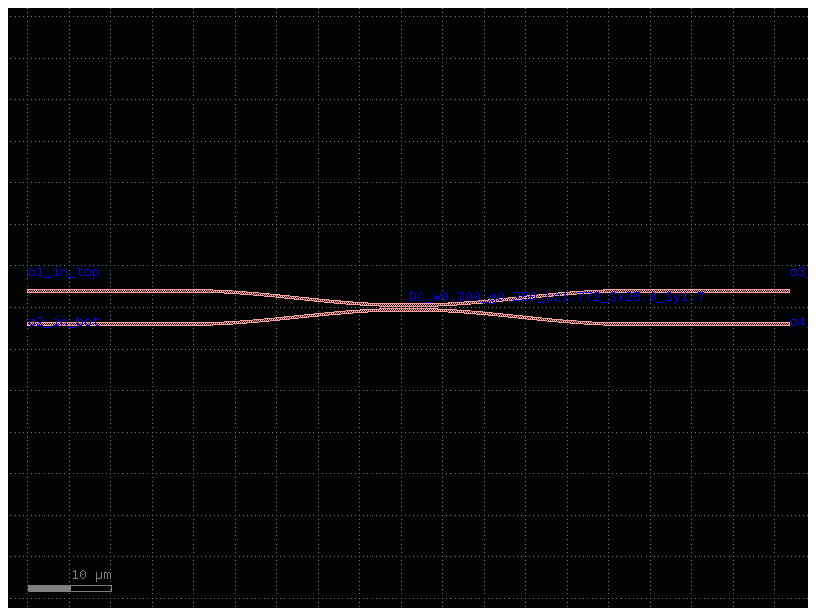

In [4]:
bs = make_tuned_beam_splitter(
    wg_width=wg_width_um,
    gap=gap_um,
    coupling_length=coupling_length_um,
    sbend_x=sbend_x_um,
    sbend_y=sbend_y_um,
    port_straight=port_straight_um,
    wg_layer=WG_LAYER,
    label_layer=LABEL_LAYER,
    num_sbend_points=num_sbend_points,
    num_straight_points=num_straight_points,
    add_labels=True,
)

bs.write_gds(gds_path)

# ------------------------------------------------------------
# Robust conversion of bs.info to a normal dictionary
# ------------------------------------------------------------
try:
    bs_info_dict = bs.info.model_dump()
except AttributeError:
    try:
        bs_info_dict = dict(bs.info)
    except TypeError:
        bs_info_dict = {}

param_record = {
    "component_name": bs.name,
    "gds_path": str(gds_path.resolve()),
    "wg_width_um": wg_width_um,
    "gap_um": gap_um,
    "coupling_length_um": coupling_length_um,
    "sbend_x_um": sbend_x_um,
    "sbend_y_um": sbend_y_um,
    "port_straight_um": port_straight_um,
    "wg_layer": WG_LAYER,
    "label_layer": LABEL_LAYER,
    "info": bs_info_dict,
}

with open(param_json_path, "w") as f:
    json.dump(param_record, f, indent=4)

print("Saved tuned beam splitter GDS:")
print(gds_path.resolve())

print("\nSaved parameter record:")
print(param_json_path.resolve())

print("\nComponent info:")
for key, value in bs_info_dict.items():
    print(f"{key:30s}: {value}")


bs.plot()

## Print port locations

In [5]:
print("Beam splitter ports")
print("-------------------")

for port in bs.ports:
    name = port.name
    center = port.center
    width = port.width
    orientation = port.orientation

    print(
        f"{name:3s} | center = ({center[0]:.3f}, {center[1]:.3f}) um "
        f"| width = {width:.3f} um "
        f"| orientation = {orientation}"
    )

Beam splitter ports
-------------------
o1  | center = (0.000, 2.000) um | width = 0.300 um | orientation = 180.0
o2  | center = (0.000, -2.000) um | width = 0.300 um | orientation = 180.0
o3  | center = (91.772, 2.000) um | width = 0.300 um | orientation = 0.0
o4  | center = (91.772, -2.000) um | width = 0.300 um | orientation = 0.0


## Locate and import lumapi

In [6]:
possible_lumapi_paths = [
    r"C:\Program Files\Lumerical\v261\api\python",
]

for p in possible_lumapi_paths:
    if Path(p).exists() and p not in sys.path:
        sys.path.append(p)
        print(f"Added lumapi path: {p}")

import lumapi

print("lumapi imported successfully.")

Added lumapi path: C:\Program Files\Lumerical\v261\api\python
lumapi imported successfully.


## Open Lumerical FDTD

In [7]:
fdtd = lumapi.FDTD(hide=False)

print("Opened Lumerical FDTD.")

Opened Lumerical FDTD.


## Global Lumerical settings

In [8]:
lambda_fit_min_um = 1.2
lambda_fit_max_um = 1.7

lambda_sim_min_um = 1.5
lambda_sim_max_um = 1.6
lambda0_um = 1.55

si_thickness_um = 0.22

# z placement of silicon device layer
si_z_min_um = 0.0
si_z_max_um = si_z_min_um + si_thickness_um

# Material names in Lumerical material database.
# Use the fitted Palik material we previously discussed.
si_material_name = "Si (Silicon) - Palik"
sio2_material_name = "SiO2 (Glass) - Palik"

# GDS import settings
gds_top_cell = "tuned_beam_splitter"
gds_layer_string = "1:0"

print("Lumerical import settings")
print("-------------------------")
print(f"GDS file:              {gds_path.resolve()}")
print(f"Top cell:              {gds_top_cell}")
print(f"GDS layer:             {gds_layer_string}")
print(f"Si material:           {si_material_name}")
print(f"Si thickness:          {si_thickness_um:.3f} um")
print(f"Si z min/max:          {si_z_min_um:.3f} / {si_z_max_um:.3f} um")
print(f"Simulation wavelength: {lambda_sim_min_um:.3f} - {lambda_sim_max_um:.3f} um")
print(f"Material fit range:    {lambda_fit_min_um:.3f} - {lambda_fit_max_um:.3f} um")

Lumerical import settings
-------------------------
GDS file:              C:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Beam Splitter Simulation\gds\tuned_beam_splitter.gds
Top cell:              tuned_beam_splitter
GDS layer:             1:0
Si material:           Si (Silicon) - Palik
Si thickness:          0.220 um
Si z min/max:          0.000 / 0.220 um
Simulation wavelength: 1.500 - 1.600 um
Material fit range:    1.200 - 1.700 um


## Clear project and set units

In [9]:
fdtd.switchtolayout()
fdtd.deleteall()

# Lumerical script variables are in SI units.
fdtd.putv("lambda_fit_min", lambda_fit_min_um * 1e-6)
fdtd.putv("lambda_fit_max", lambda_fit_max_um * 1e-6)
fdtd.putv("lambda_sim_min", lambda_sim_min_um * 1e-6)
fdtd.putv("lambda_sim_max", lambda_sim_max_um * 1e-6)
fdtd.putv("lambda0", lambda0_um * 1e-6)

print("Cleared Lumerical project.")

Cleared Lumerical project.


## Add oxide cladding / BOX background

In [10]:
total_length_um = bs.info["total_length_um"]
input_output_pitch_um = bs.info["input_output_pitch_um"]

# Simulation padding around the GDS
x_padding_um = 0.0
y_padding_um = 10.0

x_min_um = -x_padding_um
x_max_um = total_length_um + x_padding_um

y_min_um = -input_output_pitch_um / 2 - y_padding_um
y_max_um = +input_output_pitch_um / 2 + y_padding_um

# Oxide thickness around Si
box_z_min_um = -30.0
box_z_max_um = +30.0

fdtd.putv("x_min", x_min_um * 1e-6)
fdtd.putv("x_max", x_max_um * 1e-6)
fdtd.putv("y_min", y_min_um * 1e-6)
fdtd.putv("y_max", y_max_um * 1e-6)
fdtd.putv("box_z_min", box_z_min_um * 1e-6)
fdtd.putv("box_z_max", box_z_max_um * 1e-6)

fdtd.eval(f"""
switchtolayout;

addrect;
set("name", "SiO2_cladding_box");
set("material", "{sio2_material_name}");
set("x min", x_min);
set("x max", x_max);
set("y min", y_min);
set("y max", y_max);
set("z min", box_z_min);
set("z max", box_z_max);
set("alpha", 0.15);
""")

print("Added SiO2 cladding box.")
print(f"x span: {x_min_um:.3f} to {x_max_um:.3f} um")
print(f"y span: {y_min_um:.3f} to {y_max_um:.3f} um")
print(f"z span: {box_z_min_um:.3f} to {box_z_max_um:.3f} um")

Added SiO2 cladding box.
x span: -0.000 to 91.772 um
y span: -12.000 to 12.000 um
z span: -30.000 to 30.000 um


## Import GDS into Lumerical as 220 nm Si

In [11]:
gds_file_lumerical = str(gds_path.resolve()).replace("\\", "/")

fdtd.putv("gds_file", gds_file_lumerical)
fdtd.putv("si_z_min", si_z_min_um * 1e-6)
fdtd.putv("si_z_max", si_z_max_um * 1e-6)

fdtd.eval(f"""
switchtolayout;

gdsimport(
    gds_file,
    "{gds_top_cell}",
    "{gds_layer_string}",
    "{si_material_name}",
    si_z_min,
    si_z_max
);
""")

print("Imported GDS into Lumerical.")
print(f"Imported file: {gds_file_lumerical}")
print(f"Layer:         {gds_layer_string}")
print(f"Material:      {si_material_name}")
print(f"z min/max:     {si_z_min_um:.3f} / {si_z_max_um:.3f} um")

Imported GDS into Lumerical.
Imported file: C:/Users/Amirali/Desktop/Beam_Splitter_Project/lumerical_simulations/Beam Splitter Simulation/gds/tuned_beam_splitter.gds
Layer:         1:0
Material:      Si (Silicon) - Palik
z min/max:     0.000 / 0.220 um


## Add FDTD region around imported layout

In [12]:
fdtd_z_min_um = -1.5 + si_z_min_um
fdtd_z_max_um = +1.5 + si_z_max_um

mesh_accuracy = 2
simulation_time_fs = 3000

# Your preferred x/y simulation span
fdtd_x_min_um = port_straight_um - 10.0
fdtd_x_max_um = total_length_um - port_straight_um + 10.0

fdtd_y_min_um = -pitch/2 - 2.0
fdtd_y_max_um = pitch/2 + 2.0

fdtd.putv("fdtd_x_min", fdtd_x_min_um * 1e-6)
fdtd.putv("fdtd_x_max", fdtd_x_max_um * 1e-6)
fdtd.putv("fdtd_y_min", fdtd_y_min_um * 1e-6)
fdtd.putv("fdtd_y_max", fdtd_y_max_um * 1e-6)
fdtd.putv("fdtd_z_min", fdtd_z_min_um * 1e-6)
fdtd.putv("fdtd_z_max", fdtd_z_max_um * 1e-6)

fdtd.eval(f"""
switchtolayout;

addfdtd;
set("dimension", "3D");

set("x min", fdtd_x_min);
set("x max", fdtd_x_max);
set("y min", fdtd_y_min);
set("y max", fdtd_y_max);
set("z min", fdtd_z_min);
set("z max", fdtd_z_max);

set("mesh accuracy", {mesh_accuracy});

set("x min bc", "PML");
set("x max bc", "PML");
set("y min bc", "PML");
set("y max bc", "PML");
set("z min bc", "PML");
set("z max bc", "PML");

set("simulation time", {simulation_time_fs}e-15);
set("auto shutoff min", 1e-5);
""")

print("Added FDTD region.")
print(f"x span: {fdtd_x_min_um:.3f} to {fdtd_x_max_um:.3f} um")
print(f"y span: {fdtd_y_min_um:.3f} to {fdtd_y_max_um:.3f} um")
print(f"z span: {fdtd_z_min_um:.3f} to {fdtd_z_max_um:.3f} um")
print(f"mesh accuracy: {mesh_accuracy}")
print(f"simulation time: {simulation_time_fs} fs")

Added FDTD region.
x span: 10.000 to 81.772 um
y span: -4.000 to 4.000 um
z span: -1.500 to 1.720 um
mesh accuracy: 2
simulation time: 3000 fs


## Define FDTD port positions

In [13]:
port_dict = {}

for port in bs.ports:
    port_dict[port.name] = {
        "x_um": float(port.center[0]),
        "y_um": float(port.center[1]),
        "width_um": float(port.width),
        "orientation": float(port.orientation),
    }

print("Port dictionary")
print("---------------")
for name, p in port_dict.items():
    print(
        f"{name:3s}: x = {p['x_um']:.3f} um, "
        f"y = {p['y_um']:.3f} um, "
        f"width = {p['width_um']:.3f} um, "
        f"orientation = {p['orientation']:.0f}"
    )

# ------------------------------------------------------------
# FDTD port placement
# ------------------------------------------------------------
# The GDS has port_straight_um straight waveguide extensions.
# Put each port 5 um before the straight section ends.
# For port_straight_um = 20 um, this gives offset = 15 um.
# ------------------------------------------------------------
port_offset_from_edge_um = port_straight_um - 5.0

x_left_port_um = port_dict["o1"]["x_um"] + port_offset_from_edge_um
x_right_port_um = port_dict["o3"]["x_um"] - port_offset_from_edge_um

y_o1_um = port_dict["o1"]["y_um"]
y_o2_um = port_dict["o2"]["y_um"]
y_o3_um = port_dict["o3"]["y_um"]
y_o4_um = port_dict["o4"]["y_um"]

# Port transverse spans.
# Since propagation is along x, the port plane is y-z.
port_y_span_um = 7.0
port_z_span_um = 7.0

si_z_center_um = 0.5 * (si_z_min_um + si_z_max_um)

fdtd.putv("x_left_port", x_left_port_um * 1e-6)
fdtd.putv("x_right_port", x_right_port_um * 1e-6)

fdtd.putv("y_o1", y_o1_um * 1e-6)
fdtd.putv("y_o2", y_o2_um * 1e-6)
fdtd.putv("y_o3", y_o3_um * 1e-6)
fdtd.putv("y_o4", y_o4_um * 1e-6)

fdtd.putv("port_y_span", port_y_span_um * 1e-6)
fdtd.putv("port_z_span", port_z_span_um * 1e-6)
fdtd.putv("si_z_center", si_z_center_um * 1e-6)

print("\nFDTD port positions")
print("-------------------")
print(f"x_left_port_um   = {x_left_port_um:.3f}")
print(f"x_right_port_um  = {x_right_port_um:.3f}")
print(f"y_o1_um          = {y_o1_um:.3f}")
print(f"y_o2_um          = {y_o2_um:.3f}")
print(f"y_o3_um          = {y_o3_um:.3f}")
print(f"y_o4_um          = {y_o4_um:.3f}")
print(f"port_y_span_um   = {port_y_span_um:.3f}")
print(f"port_z_span_um   = {port_z_span_um:.3f}")
print(f"si_z_center_um   = {si_z_center_um:.3f}")

Port dictionary
---------------
o1 : x = 0.000 um, y = 2.000 um, width = 0.300 um, orientation = 180
o2 : x = 0.000 um, y = -2.000 um, width = 0.300 um, orientation = 180
o3 : x = 91.772 um, y = 2.000 um, width = 0.300 um, orientation = 0
o4 : x = 91.772 um, y = -2.000 um, width = 0.300 um, orientation = 0

FDTD port positions
-------------------
x_left_port_um   = 15.000
x_right_port_um  = 76.772
y_o1_um          = 2.000
y_o2_um          = -2.000
y_o3_um          = 2.000
y_o4_um          = -2.000
port_y_span_um   = 7.000
port_z_span_um   = 7.000
si_z_center_um   = 0.110


## Add 4 FDTD ports

In [14]:
fdtd.eval("""
switchtolayout;

# ------------------------------------------------------------
# Port 1 = o1, left top
# ------------------------------------------------------------
addport;
set("name", "port 1");
set("injection axis", "x-axis");
set("direction", "Forward");
set("x", x_left_port);
set("y", y_o1);
set("y span", port_y_span);
set("z", si_z_center);
set("z span", port_z_span);

# ------------------------------------------------------------
# Port 2 = o2, left bottom
# ------------------------------------------------------------
addport;
set("name", "port 2");
set("injection axis", "x-axis");
set("direction", "Forward");
set("x", x_left_port);
set("y", y_o2);
set("y span", port_y_span);
set("z", si_z_center);
set("z span", port_z_span);

# ------------------------------------------------------------
# Port 3 = o3, right top
# ------------------------------------------------------------
addport;
set("name", "port 3");
set("injection axis", "x-axis");
set("direction", "Backward");
set("x", x_right_port);
set("y", y_o3);
set("y span", port_y_span);
set("z", si_z_center);
set("z span", port_z_span);

# ------------------------------------------------------------
# Port 4 = o4, right bottom
# ------------------------------------------------------------
addport;
set("name", "port 4");
set("injection axis", "x-axis");
set("direction", "Backward");
set("x", x_right_port);
set("y", y_o4);
set("y span", port_y_span);
set("z", si_z_center);
set("z span", port_z_span);
""")

print("Added 4 FDTD ports with minimal properties.")

Added 4 FDTD ports with minimal properties.


## Set global source wavelength range

In [15]:
fdtd.eval("""
switchtolayout;

setglobalsource("wavelength start", lambda_sim_min);
setglobalsource("wavelength stop", lambda_sim_max);
""")

print("Set global source wavelength range.")
print(f"lambda start = {lambda_sim_min_um:.3f} um")
print(f"lambda stop  = {lambda_sim_max_um:.3f} um")

Set global source wavelength range.
lambda start = 1.500 um
lambda stop  = 1.600 um


## Add frequency-domain field monitor through all 4 ports

In [16]:
# ------------------------------------------------------------
# Frequency-domain monitor settings
# ------------------------------------------------------------
monitor_name = "field_monitor_all_ports"

monitor_x_min_um = x_left_port_um
monitor_x_max_um = x_right_port_um

# Include all 4 ports in y, with extra padding
monitor_y_padding_um = 2.0

monitor_y_min_um = min(y_o1_um, y_o2_um, y_o3_um, y_o4_um) - monitor_y_padding_um
monitor_y_max_um = max(y_o1_um, y_o2_um, y_o3_um, y_o4_um) + monitor_y_padding_um

# Center of 220 nm silicon layer
monitor_z_um = 0.11

# Number of wavelength / frequency points saved by the monitor
monitor_frequency_points = 101

fdtd.putv("monitor_x_min", monitor_x_min_um * 1e-6)
fdtd.putv("monitor_x_max", monitor_x_max_um * 1e-6)
fdtd.putv("monitor_y_min", monitor_y_min_um * 1e-6)
fdtd.putv("monitor_y_max", monitor_y_max_um * 1e-6)
fdtd.putv("monitor_z", monitor_z_um * 1e-6)

fdtd.eval(f"""
switchtolayout;

# Delete old monitor with the same name if it exists
if (getnamednumber("{monitor_name}") > 0) {{
    select("{monitor_name}");
    delete;
}}

addprofile;
set("name", "{monitor_name}");

# 2D horizontal field monitor at fixed z
set("monitor type", "2D Z-normal");

set("x min", monitor_x_min);
set("x max", monitor_x_max);

set("y min", monitor_y_min);
set("y max", monitor_y_max);

set("z", monitor_z);

# Frequency / wavelength sampling
set("override global monitor settings", 1);
set("use wavelength spacing", 1);
set("wavelength center", lambda0);
set("wavelength span", lambda_sim_max - lambda_sim_min);
set("frequency points", {monitor_frequency_points});

# Save field components
set("output Ex", 1);
set("output Ey", 1);
set("output Ez", 1);
set("output Hx", 1);
set("output Hy", 1);
set("output Hz", 1);
set("output power", 1);
""")

print("Added frequency-domain field monitor.")
print(f"name:        {monitor_name}")
print(f"x span:      {monitor_x_min_um:.3f} to {monitor_x_max_um:.3f} um")
print(f"y span:      {monitor_y_min_um:.3f} to {monitor_y_max_um:.3f} um")
print(f"z position:  {monitor_z_um:.3f} um")
print(f"points:      {monitor_frequency_points}")

Added frequency-domain field monitor.
name:        field_monitor_all_ports
x span:      15.000 to 76.772 um
y span:      -4.000 to 4.000 um
z position:  0.110 um
points:      101


## Save Lumerical project file

In [17]:
# ------------------------------------------------------------
# Save the Lumerical FDTD project as an .fsp file
# ------------------------------------------------------------
# Note:
# FDTD projects are saved as .fsp files, not .lms files.
# MODE projects are saved as .lms files.
#
# Since this notebook uses lumapi.FDTD(), the correct project file is .fsp.
# ------------------------------------------------------------

LUMERICAL_DIR = Path("lumerical")
LUMERICAL_DIR.mkdir(exist_ok=True)

fdtd_project_path = LUMERICAL_DIR / "tuned_beam_splitter_fdtd.fsp"
fdtd_project_path_lumerical = str(fdtd_project_path.resolve()).replace("\\", "/")

fdtd.putv("fdtd_project_path", fdtd_project_path_lumerical)

fdtd.eval("""
switchtolayout;
save(fdtd_project_path);
""")

print("Saved Lumerical FDTD project:")
print(fdtd_project_path.resolve())

Saved Lumerical FDTD project:
C:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Beam Splitter Simulation\lumerical\tuned_beam_splitter_fdtd.fsp
